In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import os
import time
from google.colab import files

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

# Mixed precision for faster training on GPU
tf.keras.mixed_precision.set_global_policy('mixed_float16')

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
BATCH_SIZE = 32
IMG_SIZE   = 128
AUTOTUNE   = tf.data.AUTOTUNE

# ImageNet normalization (same as PS preprocessing on PYNQ)
MEAN = tf.constant([0.485, 0.456, 0.406], dtype=tf.float32)
STD  = tf.constant([0.229, 0.224, 0.225], dtype=tf.float32)

(ds_train_raw, ds_val_raw), info = tfds.load(
    'cats_vs_dogs',
    split=['train[:85%]', 'train[85%:]'],
    as_supervised=True,
    with_info=True
)

total = info.splits['train'].num_examples
print(f"Train samples: {int(total * 0.85)}")
print(f"Val samples:   {int(total * 0.15)}")

Train samples: 19772
Val samples:   3489


In [ ]:
def preprocess_train(img, label):
    # Resize
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0

    # Augmentation
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.image.random_saturation(img, 0.8, 1.2)

    # Normalize with ImageNet mean/std
    img = (img - MEAN) / STD

    label = tf.cast(label, tf.float32)
    return img, label

def preprocess_val(img, label):
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    img = (img - MEAN) / STD
    label = tf.cast(label, tf.float32)
    return img, label

# Build pipelines
train_ds = (ds_train_raw
    .map(preprocess_train, num_parallel_calls=AUTOTUNE)
    .shuffle(1000)           # shuffle buffer (not full dataset)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)      # prefetch next batch while GPU trains
)

val_ds = (ds_val_raw
    .map(preprocess_val, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("Pipeline ready!")
print(f"Train batches: {len(train_ds)}")
print(f"Val batches:   {len(val_ds)}")


Pipeline ready!
Train batches: 618
Val batches:   110


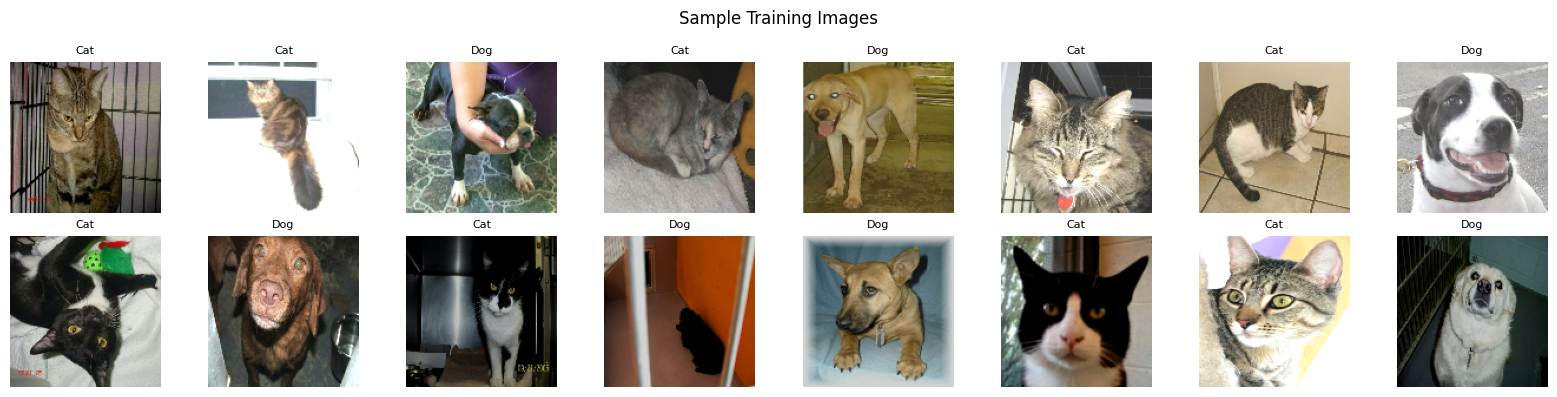

In [ ]:
def denormalize(img):
    MEAN_np = np.array([0.485, 0.456, 0.406])
    STD_np  = np.array([0.229, 0.224, 0.225])
    img     = img * STD_np + MEAN_np
    return np.clip(img, 0, 1)

imgs, labels = next(iter(train_ds))
imgs   = imgs.numpy()
labels = labels.numpy()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(denormalize(imgs[i]))
    ax.set_title('Dog' if labels[i]==1 else 'Cat', fontsize=8)
    ax.axis('off')
plt.suptitle("Sample Training Images")
plt.tight_layout()
plt.show()


In [ ]:
def build_model():
    inputs = tf.keras.Input(shape=(128, 128, 3))

    # ----------------------------------------
    # PL Layers (FPGA accelerator)
    # ----------------------------------------

    # Conv1: 3→16,  128×128 → 126×126 → 63×63
    x = tf.keras.layers.Conv2D(
            16, kernel_size=3,
            padding='valid',    # padding=0
            strides=1,
            use_bias=False,
            activation='relu'
        )(inputs)
    x = tf.keras.layers.MaxPooling2D(2)(x)

    # Conv2: 16→32, 63×63 → 61×61 → 30×30
    x = tf.keras.layers.Conv2D(
            32, kernel_size=3,
            padding='valid',
            strides=1,
            use_bias=False,
            activation='relu'
        )(x)
    x = tf.keras.layers.MaxPooling2D(2)(x)

    # Conv3: 32→64, 30×30 → 28×28 → 14×14
    x = tf.keras.layers.Conv2D(
            64, kernel_size=3,
            padding='valid',
            strides=1,
            use_bias=False,
            activation='relu'
        )(x)
    x = tf.keras.layers.MaxPooling2D(2)(x)

    # Conv4: 64→96, 14×14 → 12×12 → 6×6
    x = tf.keras.layers.Conv2D(
            96, kernel_size=3,
            padding='valid',
            strides=1,
            use_bias=False,
            activation='relu'
        )(x)
    x = tf.keras.layers.MaxPooling2D(2)(x)

    # ----------------------------------------
    # PS Layers (ARM Cortex-A9)
    # Input: 96 × 6 × 6 = 3456
    # ----------------------------------------
    x = tf.keras.layers.Flatten()(x)         # [3456]
    x = tf.keras.layers.Dense(
            128, activation='relu'
        )(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    # Output: float32 for mixed precision compatibility
    outputs = tf.keras.layers.Dense(
            1, activation='sigmoid',
            dtype='float32'
        )(x)

    model = tf.keras.Model(inputs, outputs)
    return model

model = build_model()
model.summary()

# Verify output shape
print(f"\nInput shape:  (1, 128, 128, 3)")
print(f"Output shape: {model(tf.zeros((1,128,128,3))).shape}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 96)     │        55,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3456)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       442,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 521,393 (1.99 MB)

 Trainable params: 521,393 (1.99 MB)

 Non-trainable params: 0 (0.00 B)


Input shape:  (1, 128, 128, 3)
Output shape: (1, 1)


In [ ]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(0.001),
    loss      = tf.keras.losses.BinaryCrossentropy(),
    metrics   = ['accuracy']
)

# Callbacks
callbacks = [
    # Save best model automatically
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    # Reduce LR when val_loss plateaus
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    # Stop early if no improvement
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
]

print("Starting training...")
t0 = time.time()

history = model.fit(
    train_ds,
    epochs          = 30,
    validation_data = val_ds,
    callbacks       = callbacks,
    verbose         = 1
)

print(f"\nTotal training time: {time.time()-t0:.0f}s")


Starting training...
Epoch 1/30
618/618 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.5973 - loss: 0.6606
Epoch 1: val_accuracy improved from -inf to 0.75150, saving model to best_model.keras
618/618 ━━━━━━━━━━━━━━━━━━━━ 67s 87ms/step - accuracy: 0.5974 - loss: 0.6606 - val_accuracy: 0.7515 - val_loss: 0.5040 - learning_rate: 0.0010
Epoch 2/30
617/618 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.7418 - loss: 0.5253
Epoch 2: val_accuracy improved from 0.75150 to 0.81284, saving model to best_model.keras
618/618 ━━━━━━━━━━━━━━━━━━━━ 53s 83ms/step - accuracy: 0.7419 - loss: 0.5253 - val_accuracy: 0.8128 - val_loss: 0.4059 - learning_rate: 0.0010
Epoch 3/30
614/618 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8079 - loss: 0.4282
Epoch 3: val_accuracy improved from 0.81284 to 0.84895, saving model to best_model.keras
618/618 ━━━━━━━━━━━━━━━━━━━━ 43s 67ms/step - accuracy: 0.8080 - loss: 0.4280 - val_accuracy: 0.8490 - val_loss: 0.3349 - learning_rate: 0.0010
Epoch 4/30
618/618 ━━━━━━

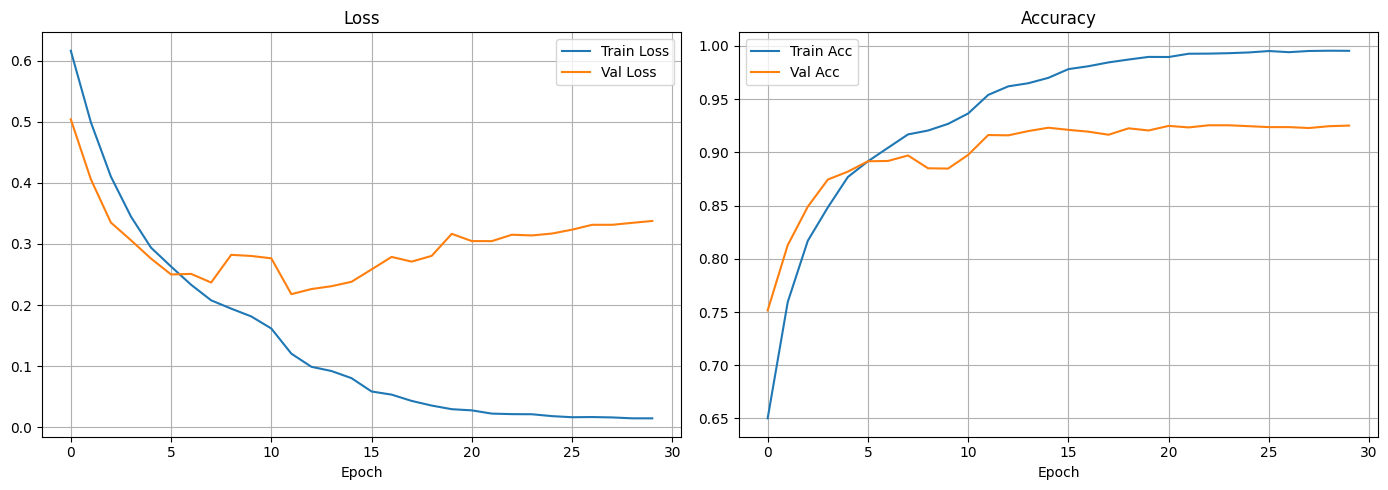

Best val accuracy: 92.55%


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'],     label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['accuracy'],     label='Train Acc')
ax2.plot(history.history['val_accuracy'], label='Val Acc')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

best_val = max(history.history['val_accuracy']) * 100
print(f"Best val accuracy: {best_val:.2f}%")

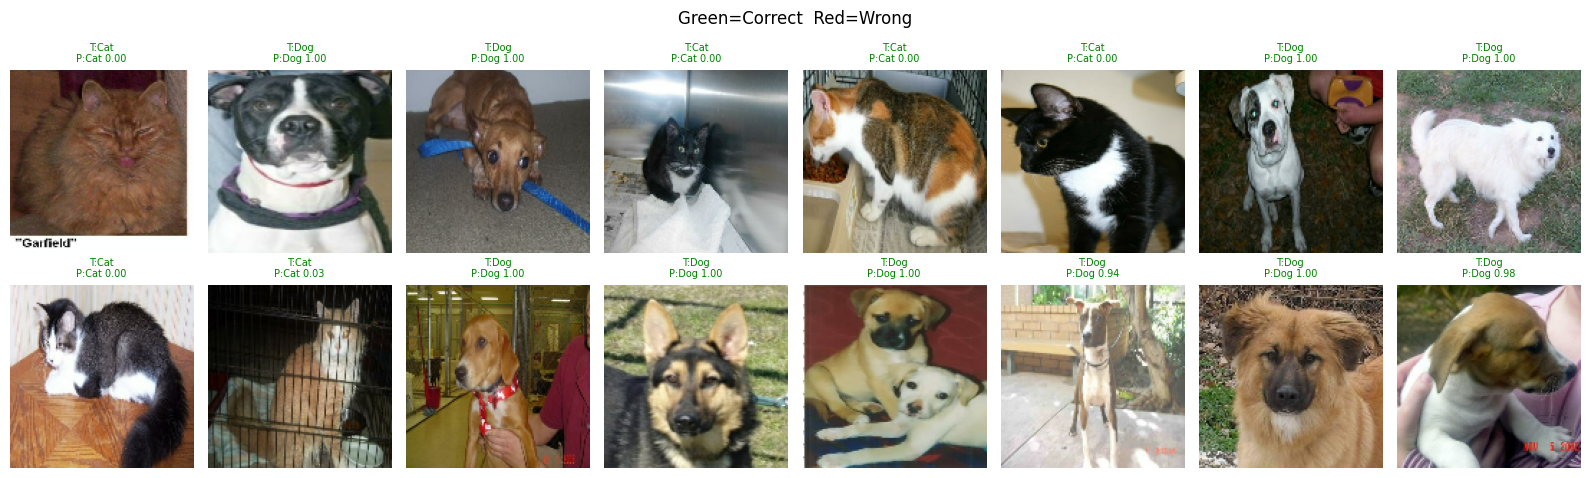

In [ ]:
imgs, labels = next(iter(val_ds))
preds  = model.predict(imgs, verbose=0).squeeze()
labels = labels.numpy()

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(denormalize(imgs[i].numpy()))
    true_l = 'Dog' if labels[i] == 1 else 'Cat'
    pred_l = 'Dog' if preds[i]  > 0.5 else 'Cat'
    color  = 'green' if true_l == pred_l else 'red'
    ax.set_title(
        f"T:{true_l}\nP:{pred_l} {preds[i]:.2f}",
        fontsize=7,
        color=color
    )
    ax.axis('off')
plt.suptitle("Green=Correct  Red=Wrong")
plt.tight_layout()
plt.show()

In [ ]:
def to_q69(arr):
    # float32 → Q6.9 int16
    return np.clip(arr * 512, -32768, 32767).astype(np.int16)

def prepare_conv_weights(w_tf, num_in_ch, num_out_ch):
    # TF conv weight shape: [kH, kW, in_ch, out_ch]
    # Need to convert to PyTorch style first:
    #   [out_ch, in_ch, kH, kW]
    # Then reorder to HW format:
    #   [out_ch, num_groups, 16, 9]

    # [kH, kW, in_ch, out_ch] → [out_ch, in_ch, kH, kW]
    w = np.transpose(w_tf, (3, 2, 0, 1))

    # Pad in_ch to multiple of 16
    num_groups = (num_in_ch + 15) // 16
    pad_ch     = num_groups * 16
    w_pad      = np.zeros(
        (num_out_ch, pad_ch, 3, 3), dtype=np.float32
    )
    w_pad[:, :num_in_ch, :, :] = w

    # Flatten 3×3 → 9 taps, group channels
    # [out_ch, num_groups, 16, 9]
    w_flat = w_pad.reshape(num_out_ch, num_groups, 16, 9)

    return to_q69(w_flat)

def export_weights(model, path='weights_for_fpga.npz'):

    # Get all layer weights
    layer_weights = {}
    for layer in model.layers:
        if layer.get_weights():
            layer_weights[layer.name] = layer.get_weights()

    print("Layers with weights:")
    for name, wlist in layer_weights.items():
        for i, w in enumerate(wlist):
            print(f"  {name}[{i}]: {w.shape}  "
                  f"range [{w.min():.3f}, {w.max():.3f}]")

    # Extract conv layers in order
    conv_layers = [l for l in model.layers
                   if isinstance(l, tf.keras.layers.Conv2D)]
    dense_layers = [l for l in model.layers
                    if isinstance(l, tf.keras.layers.Dense)]

    print(f"\nFound {len(conv_layers)} conv layers")
    print(f"Found {len(dense_layers)} dense layers")

    # Conv weights: reorder for HW
    configs = [
        (3,  16),   # conv1
        (16, 32),   # conv2
        (32, 64),   # conv3
        (64, 96),   # conv4
    ]

    conv_hw = []
    for i, (layer, (in_ch, out_ch)) in enumerate(
            zip(conv_layers, configs)):
        w    = layer.get_weights()[0]  # [3,3,in_ch,out_ch]
        w_hw = prepare_conv_weights(w, in_ch, out_ch)
        conv_hw.append(w_hw)
        print(f"conv{i+1}: {w.shape} → HW {w_hw.shape}")

    # Dense weights
    # dense_layers[0] = fc1 (128 units)
    # dense_layers[1] = fc2 (1 unit)
    fc1_w, fc1_b = dense_layers[0].get_weights()
    fc2_w, fc2_b = dense_layers[1].get_weights()

    # TF Dense weight shape: [in, out]
    # Need [out, in] for matrix multiply on PS
    fc1_w = fc1_w.T   # [3456, 128] → [128, 3456]
    fc2_w = fc2_w.T   # [128,  1  ] → [1,   128 ]

    # Check for Q6.9 overflow in conv weights
    print("\nQ6.9 overflow check (max abs should be < 64):")
    for i, w in enumerate(conv_hw):
        orig = conv_layers[i].get_weights()[0]
        mx   = np.abs(orig).max()
        ok   = '✓' if mx < 64 else '✗ OVERFLOW!'
        print(f"  conv{i+1}: max_abs={mx:.4f} {ok}")

    # Save
    np.savez(path,
        # Conv weights: Q6.9 int16, HW format
        conv1_weight = conv_hw[0],
        conv2_weight = conv_hw[1],
        conv3_weight = conv_hw[2],
        conv4_weight = conv_hw[3],
        # FC weights: float32, for PS ARM
        fc1_weight   = fc1_w.astype(np.float32),
        fc1_bias     = fc1_b.astype(np.float32),
        fc2_weight   = fc2_w.astype(np.float32),
        fc2_bias     = fc2_b.astype(np.float32),
        # Normalization: stored so PS can verify
        norm_mean    = np.array([0.485, 0.456, 0.406],
                                dtype=np.float32),
        norm_std     = np.array([0.229, 0.224, 0.225],
                                dtype=np.float32),
    )

    # Verify
    print(f"\nSaved to: {path}")
    check = np.load(path)
    print("Contents:")
    for k in check.files:
        arr = check[k]
        print(f"  {k:20s}: shape={str(arr.shape):20s} "
              f"dtype={arr.dtype}")

export_weights(model)


Layers with weights:
  conv2d[0]: (3, 3, 3, 16)  range [-0.312, 0.357]
  conv2d_1[0]: (3, 3, 16, 32)  range [-0.405, 0.377]
  conv2d_2[0]: (3, 3, 32, 64)  range [-0.520, 0.365]
  conv2d_3[0]: (3, 3, 64, 96)  range [-0.532, 0.377]
  dense[0]: (3456, 128)  range [-0.418, 0.469]
  dense[1]: (128,)  range [-0.093, 0.385]
  dense_1[0]: (128, 1)  range [-0.312, 0.226]
  dense_1[1]: (1,)  range [-0.067, -0.067]

Found 4 conv layers
Found 2 dense layers
conv1: (3, 3, 3, 16) → HW (16, 1, 16, 9)
conv2: (3, 3, 16, 32) → HW (32, 1, 16, 9)
conv3: (3, 3, 32, 64) → HW (64, 2, 16, 9)
conv4: (3, 3, 64, 96) → HW (96, 4, 16, 9)

Q6.9 overflow check (max abs should be < 64):
  conv1: max_abs=0.3572 ✓
  conv2: max_abs=0.4051 ✓
  conv3: max_abs=0.5198 ✓
  conv4: max_abs=0.5319 ✓

Saved to: weights_for_fpga.npz
Contents:
  conv1_weight        : shape=(16, 1, 16, 9)       dtype=int16
  conv2_weight        : shape=(32, 1, 16, 9)       dtype=int16
  conv3_weight        : shape=(64, 2, 16, 9)       dtype=int16
 

In [ ]:
files.download('weights_for_fpga.npz')
files.download('training_curves.png')
model.save('dogcat_model.keras')
files.download('dogcat_model.keras')

print("\nDone!")
print("Copy weights_for_fpga.npz to PYNQ at:")
print("  /home/xilinx/weights_for_fpga.npz")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done!
Copy weights_for_fpga.npz to PYNQ at:
  /home/xilinx/weights_for_fpga.npz


In [ ]:
weights = np.load('weights_for_fpga.npz')
c1 = weights['conv1_weight']   # shape (16, 1, 16, 9)

print("Conv1 weight verification:")
print(f"  Shape: {c1.shape}")
print(f"  Channels 0-2 (real): non-zero count = "
      f"{np.count_nonzero(c1[:, 0, :3, :])}")
print(f"  Channels 3-15 (pad): non-zero count = "
      f"{np.count_nonzero(c1[:, 0, 3:, :])}")

Conv1 weight verification:
  Shape: (16, 1, 16, 9)
  Channels 0-2 (real): non-zero count = 428
  Channels 3-15 (pad): non-zero count = 0
